In [1]:
import pandas as pd

ot_df = pd.read_csv("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/ot_consult.csv", parse_dates=["ot_time"])
pt_df = pd.read_csv("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/pt_consult.csv", parse_dates=["pt_time"])
final_df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/mobilization_output/intermediate/cohort_all_ids_w_outcome.parquet")

In [2]:
def _ensure_datetime_naive(s: pd.Series) -> pd.Series:
    """Parse to datetime; if tz-aware, drop tz to make naive."""
    s = pd.to_datetime(s, errors='coerce')
    try:
        return s.dt.tz_localize(None)
    except TypeError:
        return s

def _prep_orders(df: pd.DataFrame, *, discipline: str) -> pd.DataFrame:
    """
    Return standardized orders with columns:
      ['patient_id','hospitalization_id','order_dttm','discipline']
    Uses ot_time or pt_time.
    """
    time_cols_pref = ['ot_time', 'pt_time']
    time_col = next((c for c in time_cols_pref if c in df.columns), None)

    tmp = df.copy()

    if 'hospitalization_id' not in tmp.columns and 'hadm_id' in tmp.columns:
        tmp = tmp.rename(columns={'hadm_id': 'hospitalization_id'})

    keep_cols = [c for c in ['patient_id', 'hospitalization_id', time_col] if c in tmp.columns]
    out = tmp[keep_cols].copy()

    out['order_dttm'] = pd.to_datetime(out[time_col], errors='coerce')
    out['hospitalization_id'] = out['hospitalization_id'].astype(str)
    out['patient_id'] = out['patient_id'].astype(str)
    out = out.drop(columns=[time_col])
    out['discipline'] = discipline

    return out

In [3]:
ot_orders = _prep_orders(ot_df, discipline='OT')
pt_orders = _prep_orders(pt_df, discipline='PT')
orders = pd.concat([ot_orders, pt_orders], ignore_index=True)

In [4]:
final_df['block_vent_start_dttm'] = _ensure_datetime_naive(final_df['block_vent_start_dttm'])
final_df['block_first_vital_dttm'] = _ensure_datetime_naive(final_df['block_first_vital_dttm'])
blocks = final_df[['patient_id', 'hospitalization_id', 'encounter_block',
                   'block_vent_start_dttm', 'block_first_vital_dttm']].copy()

In [5]:
merged = (blocks.merge(orders, on=['patient_id', 'hospitalization_id'], how='left'))

mask_after_vital = merged['order_dttm'] >= merged['block_first_vital_dttm']
mask_before_vent  = merged['order_dttm'] < merged['block_vent_start_dttm']

merged = merged.loc[mask_after_vital & mask_before_vent].copy()

In [7]:
pre_window = merged.loc[mask_after_vital & mask_before_vent,
                        ['patient_id','hospitalization_id','encounter_block',
                         'discipline','order_dttm']].copy()

last_per_block = (
    pre_window
    .groupby(['patient_id','hospitalization_id','encounter_block','discipline'], as_index=False)
    .agg(last_pre_imv_dttm=('order_dttm', 'max'))
)

In [8]:
last_wide = (
    last_per_block
    .pivot(index=['patient_id','hospitalization_id','encounter_block'],
           columns='discipline',
           values='last_pre_imv_dttm')
    .reset_index()
    .rename(columns={'OT': 'last_ot_pre_imv_dttm',
                     'PT': 'last_pt_pre_imv_dttm'})
)

In [9]:
last_wide.head()

discipline,patient_id,hospitalization_id,encounter_block,last_ot_pre_imv_dttm,last_pt_pre_imv_dttm
0,10004422,21255400,288,NaT,2111-01-17 12:00:00
1,10005348,25239799,331,NaT,2130-10-27 12:24:00
2,10005606,29646384,343,2143-12-06 12:35:00,2143-12-06 12:35:00
3,10009628,25926192,550,NaT,2153-09-19 12:26:00
4,10011938,28265343,692,2133-12-11 00:58:00,2133-12-11 00:58:00


In [10]:
last_wide['last_any_pre_imv_dttm'] = last_wide[
    ['last_ot_pre_imv_dttm', 'last_pt_pre_imv_dttm']
].max(axis=1)

# Attach back to blocks, keeping all blocks
final_df_pre_imv = final_df.merge(
    last_wide,
    on=['patient_id','hospitalization_id','encounter_block'],
    how='left'
)
final_df_pre_imv.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,final_outcome_dttm,is_dead,last_ot_pre_imv_dttm,last_pt_pre_imv_dttm,last_any_pre_imv_dttm
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00,2131-01-19 19:59:59-05:00,2131-01-11 04:20:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,2131-01-20 04:19:00-05:00,1,NaT,NaT,NaT
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00,2160-05-18 20:59:59-05:00,2160-05-18 10:00:00,2160-05-19 16:00:00-05:00,NaT,2160-05-19 16:00:00-05:00,0,NaT,NaT,NaT
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00,2162-02-19 21:59:59-05:00,2162-02-17 22:33:00,2162-02-20 19:06:00-05:00,NaT,2162-02-20 19:06:00-05:00,0,NaT,NaT,NaT
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00,2156-04-22 16:59:59-05:00,2156-04-12 16:24:00,2156-04-26 18:00:00-05:00,NaT,2156-04-26 18:00:00-05:00,0,NaT,NaT,NaT
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00,2156-05-21 04:59:59-05:00,2156-05-11 14:49:00,2156-05-22 13:00:00-05:00,NaT,2156-05-22 13:00:00-05:00,0,NaT,NaT,NaT


In [11]:
delta_ot = final_df_pre_imv["last_ot_pre_imv_dttm"] - final_df_pre_imv["block_vent_start_dttm"]
final_df_pre_imv["Time_last_OT"] = (delta_ot.dt.round("h") / pd.Timedelta(hours=1)).astype("Int64")

delta_pt = final_df_pre_imv["last_pt_pre_imv_dttm"] - final_df_pre_imv["block_vent_start_dttm"]
final_df_pre_imv["Time_last_PT"] = (delta_pt.dt.round("h") / pd.Timedelta(hours=1)).astype("Int64")

final_df_pre_imv["Time_last_OT_or_PT"] = (
    final_df_pre_imv[["Time_last_OT", "Time_last_PT"]]
    .min(axis=1)
)

In [1]:
final_df_pre_imv.to_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_pre_imv.parquet")

In [17]:
final_df_pre_imv = final_df_pre_imv.drop_duplicates(subset=['encounter_block'], keep="first")
#final_df_pre_imv.info()
final_df_post_imv.to_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_pre_imv1.parquet")

In [18]:
n_unique_blocks = final_df_pre_imv['encounter_block'].nunique()

non_missing_counts = final_df_pre_imv[
    ['last_ot_pre_imv_dttm','last_pt_pre_imv_dttm','last_any_pre_imv_dttm']
].notna().sum()

print("Unique encounter_block:", n_unique_blocks)
print("\nNon-missing values per column:\n", non_missing_counts)

Unique encounter_block: 32126

Non-missing values per column:
 last_ot_pre_imv_dttm      617
last_pt_pre_imv_dttm     2324
last_any_pre_imv_dttm    2335
dtype: int64


# Summary statistics

In [13]:
import numpy as np

cols = ["Time_last_OT", "Time_last_PT", "Time_last_OT_or_PT"]
q1 = final_df_pre_imv[cols].quantile(0.25)
q3 = final_df_pre_imv[cols].quantile(0.75)
iqr = q3 - q1

stats_df = pd.DataFrame({
    "count": final_df_pre_imv[cols].count(),
    "min": final_df_pre_imv[cols].min(),
    "q1": q1,
    "median": final_df_pre_imv[cols].median(),
    "q3": q3,
    "IQR": iqr,
    "mean": final_df_pre_imv[cols].mean(),
    "sd": final_df_pre_imv[cols].std(),
    "max": final_df_pre_imv[cols].max()
}).round(2)

display(stats_df)

,count,min,q1,median,q3,IQR,mean,sd,max
Time_last_OT,617,-1246,-48,-11.0,-2,46,-55.8,124.59,0
Time_last_PT,2324,-1246,-7,-2.0,-1,6,-23.22,77.87,0
Time_last_OT_or_PT,2335,-1246,-7,-2.0,-1,6,-23.17,77.7,0


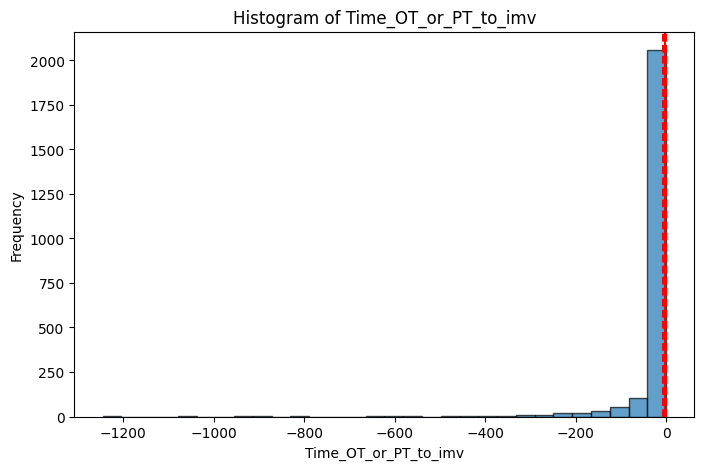

In [17]:
import matplotlib.pyplot as plt

data = final_df_pre_imv["Time_last_OT_or_PT"].dropna()
median = data.median()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

plt.figure(figsize=(8,5))
plt.hist(data, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(median, color="r", linestyle="-")
plt.axvline(q1, color="r", linestyle="--")
plt.axvline(q3, color="r", linestyle="--")
plt.xlabel("Time_OT_or_PT_to_imv")
plt.ylabel("Frequency")
plt.title("Histogram of Time_OT_or_PT_to_imv")

#plt.savefig("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/graphs/pre_imv_hist.png", dpi=300, bbox_inches="tight")

plt.show()

In [2]:
import pandas as pd

post_imv = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_post_imv.parquet")
post_imv.columns.tolist()

['patient_id',
 'hospitalization_id',
 'encounter_block',
 'discharge_category',
 'discharge_dttm',
 'block_vent_start_dttm',
 'block_vent_end_dttm',
 'block_first_vital_dttm',
 'block_last_vital_dttm',
 'death_dttm',
 'final_outcome_dttm',
 'is_dead',
 'first_ot_post_imv_dttm',
 'first_pt_post_imv_dttm',
 'first_any_post_imv_dttm',
 'Time_first_OT',
 'Time_first_PT',
 'Time_first_OT_or_PT',
 'yellow_time_eligibility',
 'delayed_yellow_PT',
 'delayed_yellow_OT',
 'delayed_yellow_OT_or_PT']

In [3]:
pre_imv = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/OT_PT_pre_imv.parquet")
pre_imv.columns.tolist()

['patient_id',
 'hospitalization_id',
 'encounter_block',
 'discharge_category',
 'discharge_dttm',
 'block_vent_start_dttm',
 'block_vent_end_dttm',
 'block_first_vital_dttm',
 'block_last_vital_dttm',
 'death_dttm',
 'final_outcome_dttm',
 'is_dead',
 'last_ot_pre_imv_dttm',
 'last_pt_pre_imv_dttm',
 'last_any_pre_imv_dttm',
 'Time_last_OT',
 'Time_last_PT',
 'Time_last_OT_or_PT']

In [4]:
keys = ["hospitalization_id", "patient_id", "encounter_block"]

# Keep only the two columns we need from pre_imv (+ keys) and ensure 1 row per key
pre_add = (
    pre_imv.loc[:, keys + ["last_pt_pre_imv_dttm", "Time_last_PT"]]
    .drop_duplicates(subset=keys, keep="first")
)

# Left-merge so all post_imv rows are preserved
merged_df = post_imv.merge(pre_add, on=keys, how="left")
merged_df.head()

,patient_id,hospitalization_id,encounter_block,discharge_category,discharge_dttm,block_vent_start_dttm,block_vent_end_dttm,block_first_vital_dttm,block_last_vital_dttm,death_dttm,...,first_any_post_imv_dttm,Time_first_OT,Time_first_PT,Time_first_OT_or_PT,yellow_time_eligibility,delayed_yellow_PT,delayed_yellow_OT,delayed_yellow_OT_or_PT,last_pt_pre_imv_dttm,Time_last_PT
0,10001884,26184834,97,Expired,2131-01-20 05:15:00-05:00,2131-01-11 04:00:00,2131-01-19 19:59:59,2131-01-11 04:20:00-05:00,2131-01-20 04:19:00-05:00,2131-01-20 05:15:00-05:00,...,2131-01-11 18:37:00,15,15,15,4.0,11.0,11.0,11.0,NaT,<NA>
1,10002013,23581541,104,Home,2160-05-23 13:30:00-05:00,2160-05-18 14:00:00,2160-05-18 20:59:59,2160-05-18 10:00:00-05:00,2160-05-19 16:00:00-05:00,NaT,...,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>,NaT,<NA>
2,10002114,27793700,118,Home,2162-03-04 15:16:00-05:00,2162-02-17 23:00:00,2162-02-19 21:59:59,2162-02-17 22:33:00-05:00,2162-02-20 19:06:00-05:00,NaT,...,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>,NaT,<NA>
3,10002428,28662225,141,Skilled Nursing Facility (SNF),2156-04-29 16:26:00-05:00,2156-04-19 20:00:00,2156-04-22 16:59:59,2156-04-12 16:24:00-05:00,2156-04-26 18:00:00-05:00,NaT,...,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>,NaT,<NA>
4,10002428,23473524,143,Long Term Care Hospital (LTACH),2156-05-22 14:16:00-05:00,2156-05-11 16:00:00,2156-05-21 04:59:59,2156-05-11 14:49:00-05:00,2156-05-22 13:00:00-05:00,NaT,...,NaT,<NA>,<NA>,<NA>,4.0,<NA>,<NA>,<NA>,NaT,<NA>


In [5]:
merged_df.columns.tolist()

['patient_id',
 'hospitalization_id',
 'encounter_block',
 'discharge_category',
 'discharge_dttm',
 'block_vent_start_dttm',
 'block_vent_end_dttm',
 'block_first_vital_dttm',
 'block_last_vital_dttm',
 'death_dttm',
 'final_outcome_dttm',
 'is_dead',
 'first_ot_post_imv_dttm',
 'first_pt_post_imv_dttm',
 'first_any_post_imv_dttm',
 'Time_first_OT',
 'Time_first_PT',
 'Time_first_OT_or_PT',
 'yellow_time_eligibility',
 'delayed_yellow_PT',
 'delayed_yellow_OT',
 'delayed_yellow_OT_or_PT',
 'last_pt_pre_imv_dttm',
 'Time_last_PT']

In [6]:
merged_df.to_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/PT_prior_post_imv.parquet")